
# PRÁCTICA: Comparación KNN vs Regresión Logística vs SVM  
## Dataset: Breast Cancer Wisconsin

**Instrucciones**
- Puedes desarrollar tu código en las celdas que se faciliten. En algunos casos, hay alguna ayuda.
- Si prefieres otra forma de desarrollo también es válida. Completa el trahajo con tus propios comentarios


---
## 0️⃣ Imports y configuración

In [117]:

# Importa lo necesario para:
# - pandas, numpy
# - train_test_split
# - StandardScaler
# - SimpleImputer (si hay NaN)
# - KNeighborsClassifier
# - LogisticRegression
# - SVC
# - métricas: accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
# - matplotlib.pyplot

# Escribe aquí tus imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_circles
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, mean_squared_error, roc_curve, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix

---
## 1️⃣ Carga y exploración del dataset

In [93]:

# Carga el CSV (ajusta el nombre si es necesario)

# Muestra shape y primeras filas

# Identifica la columna objetivo (normalmente 'diagnosis')

# Comprueba valores

# Comprueba balanceo de clases


In [94]:
df_cancer = pd.read_csv("breat_cancer_wisconsin_dataset.csv")
df_cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [95]:
df_cancer.shape

(569, 33)

In [96]:
df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [97]:
counts = df_cancer["diagnosis"].value_counts()
print(counts)
print(f"\nRatio: {counts.max() / counts.min():.2f}x")

diagnosis
B    357
M    212
Name: count, dtype: int64

Ratio: 1.68x


In [98]:
df_cancer.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:


**Pregunta (responder en una frase):**  
- ¿El dataset está balanceado?  
    - No esta del todo balanceado ya que hay 357 B y 212 M.
- ¿Hay NaN? Si los hay, ¿qué estrategia usarás (drop vs imputación) y por qué?
    - Hay una columna que todos sus valores son NaN, en este caso deberiamos borrar la columna ya que como todos sus registros no nos aportan nada pues
    podriamos perfectamente eliminar dicha columna.


---
## 2️⃣ Limpieza mínima + definición de X e y

In [99]:
df_cancer.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [100]:
df_cancer["diagnosis"] = df_cancer["diagnosis"].map({"M": 1, "B": 0})

In [101]:
df_cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [102]:
df_cancer.corr(numeric_only=True)["diagnosis"].abs().sort_values(ascending=False)[1:]

concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
smoothness_se              0.067016
id                         0

In [103]:
df_cancer.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [104]:

# Elimina columnas irrelevantes si existen (típicas: 'id', 'Unnamed: 32', 'Unnamed: 0')
df_cancer.drop(columns=["id", "Unnamed: 32"], inplace=True)


In [105]:
# Define X e y
X = df_cancer.drop(["diagnosis"],axis=1)
y = df_cancer["diagnosis"]

# Verifica shapes
print(X.shape)
print(y.shape)


(569, 30)
(569,)


---
## 3️⃣ Train/Test split

In [106]:

# Divide en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y)

# Verifica el resultado
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (455, 30)
X_test:  (114, 30)
y_train: (455,)
y_test:  (114,)


---
## 4️⃣ Tratamiento de NaN + Escalado (obligatorio para KNN y SVM)

In [107]:

# Decisiones a tomar si hay NaN

# Si NO hay NaN

# Escala con StandardScaler (fit en train, transform en test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verifica que no quedan NaN
df_cancer.isna().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


**Pregunta**  
¿Por qué es obligatorio escalar en KNN y SVM?


---
## 5️⃣ Modelo 1: KNN (búsqueda de k)

In [114]:

# Recorre k impares (puedes consultar la teoría)
# Calcula y guarda:
# - accuracy (en test)
# - AUC (en test) usando predict_proba

# Identifica el mejor k según accuracy y el mejor k según AUC

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

resultados = []

# Recorre k impares del 1 al 21
for k in range(1, 22, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred  = knn.predict(X_test)
    y_proba = knn.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    resultados.append({"k": k, "accuracy": acc, "auc": auc})

# Convertir a DataFrame para verlo bien
import pandas as pd
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

# Mejor k según accuracy
mejor_acc = df_resultados.loc[df_resultados["accuracy"].idxmax()]
print(f"\nMejor k por Accuracy : k={int(mejor_acc['k'])}  → {mejor_acc['accuracy']:.4f}")

# Mejor k según AUC
mejor_auc = df_resultados.loc[df_resultados["auc"].idxmax()]
print(f"Mejor k por AUC      : k={int(mejor_auc['k'])}  → {mejor_auc['auc']:.4f}")


 k  accuracy      auc
 1  0.894737 0.872024
 3  0.921053 0.897321
 5  0.912281 0.954696
 7  0.912281 0.977348
 9  0.921053 0.975860
11  0.947368 0.979167
13  0.938596 0.980985
15  0.929825 0.979663
17  0.938596 0.979167
19  0.938596 0.978009
21  0.929825 0.979332

Mejor k por Accuracy : k=11  → 0.9474
Mejor k por AUC      : k=13  → 0.9810


---
## 6️⃣ Gráfica: superponer Accuracy y AUC vs k

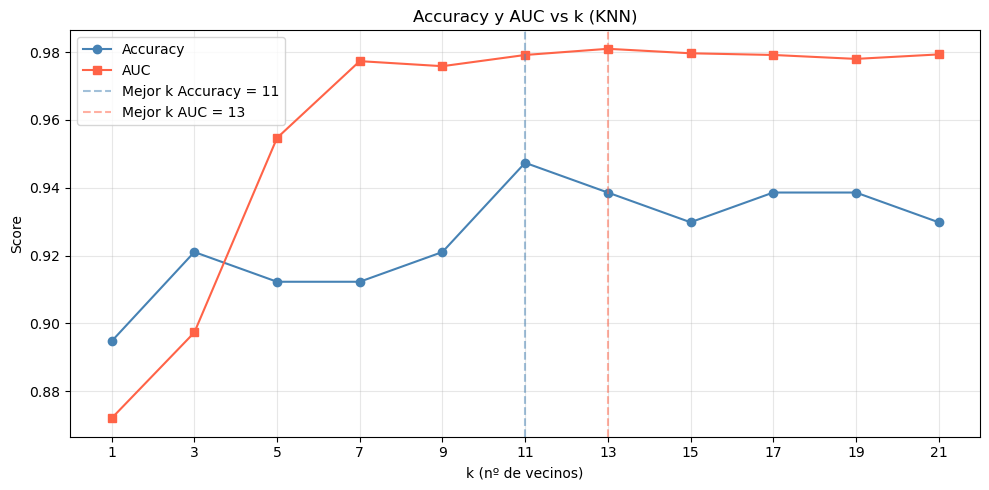

In [115]:

# Representa en el mismo gráfico accuracy y AUC vs k

plt.figure(figsize=(10, 5))

plt.plot(df_resultados["k"], df_resultados["accuracy"], marker="o", label="Accuracy", color="steelblue")
plt.plot(df_resultados["k"], df_resultados["auc"],      marker="s", label="AUC",      color="tomato")

# Líneas verticales en los mejores k
plt.axvline(x=mejor_acc["k"], color="steelblue", linestyle="--", alpha=0.5, label=f"Mejor k Accuracy = {int(mejor_acc['k'])}")
plt.axvline(x=mejor_auc["k"], color="tomato",    linestyle="--", alpha=0.5, label=f"Mejor k AUC = {int(mejor_auc['k'])}")

plt.title("Accuracy y AUC vs k (KNN)")
plt.xlabel("k (nº de vecinos)")
plt.ylabel("Score")
plt.xticks(df_resultados["k"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Pregunta**  
¿Coincide el mejor k según Accuracy con el mejor k según AUC? ¿Por qué podría no coincidir?


---
## 7️⃣ Entrena el KNN final (elige un k) + métricas

k final elegido: 13

Accuracy: 0.9386


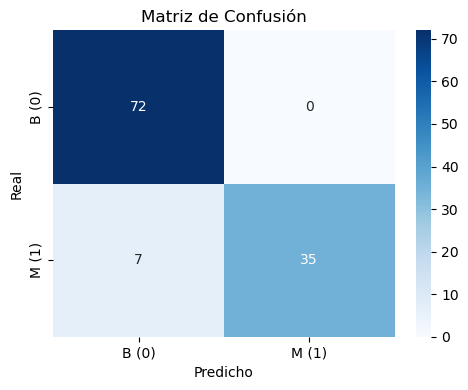


Classification Report:
              precision    recall  f1-score   support

 Benigno (0)       0.91      1.00      0.95        72
 Maligno (1)       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



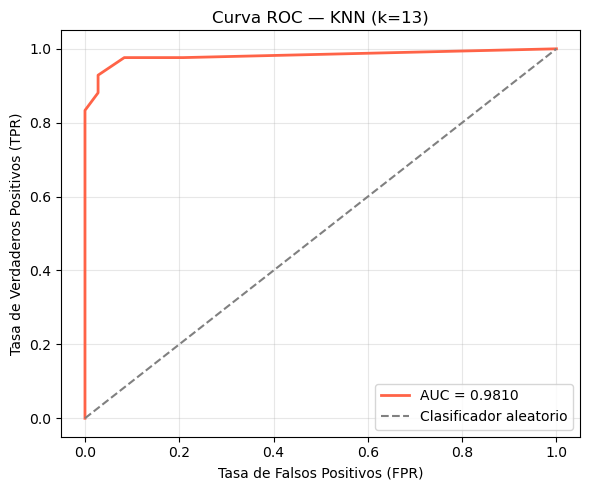

In [118]:

# Elige k final (puede ser best_k_auc o un criterio razonado)
k_final = int(mejor_auc["k"])
print(f"k final elegido: {k_final}")

# Entrena y evalúa:
knn_final = KNeighborsClassifier(n_neighbors=k_final)
knn_final.fit(X_train, y_train)

y_pred  = knn_final.predict(X_test)
y_proba = knn_final.predict_proba(X_test)[:, 1]

# - accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

# - matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["B (0)", "M (1)"],
            yticklabels=["B (0)", "M (1)"])
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# - classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benigno (0)", "Maligno (1)"]))

# - curva ROC + AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="tomato", lw=2, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Clasificador aleatorio")
plt.title(f"Curva ROC — KNN (k={k_final})")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



---
## 8️⃣ Modelo 2: Regresión Logística

Accuracy: 0.9386


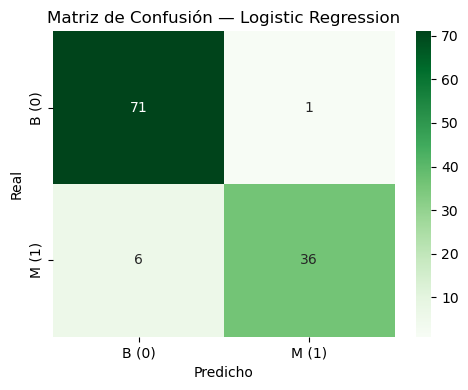

AUC: 0.9924


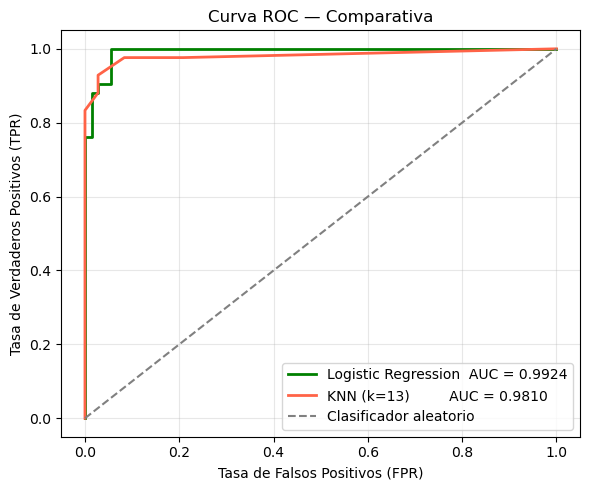

In [119]:

# Entrena LogisticRegression (max_iter suficiente)
modelo_lr = LogisticRegression(max_iter=10000, random_state=42)
modelo_lr.fit(X_train, y_train)

y_pred_lr  = modelo_lr.predict(X_test)
y_proba_lr = modelo_lr.predict_proba(X_test)[:, 1]

# Evalúa:
# - accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr:.4f}")

# - matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["B (0)", "M (1)"],
            yticklabels=["B (0)", "M (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# - AUC
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"AUC: {auc_lr:.4f}")

# - curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color="green", lw=2, label=f"Logistic Regression  AUC = {auc_lr:.4f}")
plt.plot(fpr, tpr,       color="tomato", lw=2, label=f"KNN (k={k_final})         AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Clasificador aleatorio")
plt.title("Curva ROC — Comparativa")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 9️⃣ Modelo 3: SVM

In [120]:

valores_C = [0.1, 1, 5, 10, 50, 100]
valores_gamma = [0.001, 0.01, 0.1, 1]
valores_degree = [2, 3, 4, 5]
valores_coef0 = [0, 0.5, 1, 2]

# Funcion que recibe como parametro el tipo de kernel para entrenar el modelo con distintos hiperparametros almacenados en listas
def mejor_eleccion(kernel):
    mejor_acc = 0
    mejor_config = None

    for C in valores_C:

        # LINEAR
        if kernel == 'linear':
            print(f"\nProbando LINEAR | C={C}")

            svm = SVC(kernel='linear', C=C, random_state=42)

            svm.fit(X_train_scaled, y_train)
            pred = svm.predict(X_test_scaled)
            acc = accuracy_score(y_test, pred)

            print(f"Accuracy: {acc:.4f}")

            if acc > mejor_acc:
                mejor_acc = acc
                mejor_config = ('linear', C)

        # RBF
        elif kernel == 'rbf':
            for gamma in valores_gamma:
                print(f"\nProbando RBF | C={C} | gamma={gamma}")

                svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)

                svm.fit(X_train_scaled, y_train)
                pred = svm.predict(X_test_scaled)
                acc = accuracy_score(y_test, pred)

                print(f"Accuracy: {acc:.4f}")

                if acc > mejor_acc:
                    mejor_acc = acc
                    mejor_config = ('rbf', C, gamma)

        # POLY 
        elif kernel == 'poly':
            for degree in valores_degree:
                for coef0 in valores_coef0:
                    print(f"\nProbando POLY | C={C} | degree={degree} | coef0={coef0}")

                    svm = SVC(kernel='poly', C=C, degree=degree, coef0=coef0, random_state=42)

                    svm.fit(X_train_scaled, y_train)
                    pred = svm.predict(X_test_scaled)
                    acc = accuracy_score(y_test, pred)

                    print(f"Accuracy: {acc:.4f}")

                    if acc > mejor_acc:
                        mejor_acc = acc
                        mejor_config = ('poly', C, degree, coef0)

    print(f"\nMejor Accuracy: {mejor_acc:.4f}")
    print(f"Mejor configuración: {mejor_config}")


In [123]:
mejor_eleccion("rbf")


Probando RBF | C=0.1 | gamma=0.001
Accuracy: 0.7719

Probando RBF | C=0.1 | gamma=0.01
Accuracy: 0.9474

Probando RBF | C=0.1 | gamma=0.1
Accuracy: 0.8947

Probando RBF | C=0.1 | gamma=1
Accuracy: 0.6316

Probando RBF | C=1 | gamma=0.001
Accuracy: 0.9386

Probando RBF | C=1 | gamma=0.01
Accuracy: 0.9561

Probando RBF | C=1 | gamma=0.1
Accuracy: 0.9298

Probando RBF | C=1 | gamma=1
Accuracy: 0.6316

Probando RBF | C=5 | gamma=0.001
Accuracy: 0.9561

Probando RBF | C=5 | gamma=0.01
Accuracy: 0.9825

Probando RBF | C=5 | gamma=0.1
Accuracy: 0.9474

Probando RBF | C=5 | gamma=1
Accuracy: 0.6316

Probando RBF | C=10 | gamma=0.001
Accuracy: 0.9649

Probando RBF | C=10 | gamma=0.01
Accuracy: 0.9825

Probando RBF | C=10 | gamma=0.1
Accuracy: 0.9561

Probando RBF | C=10 | gamma=1
Accuracy: 0.6316

Probando RBF | C=50 | gamma=0.001
Accuracy: 0.9825

Probando RBF | C=50 | gamma=0.01
Accuracy: 0.9649

Probando RBF | C=50 | gamma=0.1
Accuracy: 0.9386

Probando RBF | C=50 | gamma=1
Accuracy: 0.6316

Accuracy : 0.9825
AUC      : 0.9974


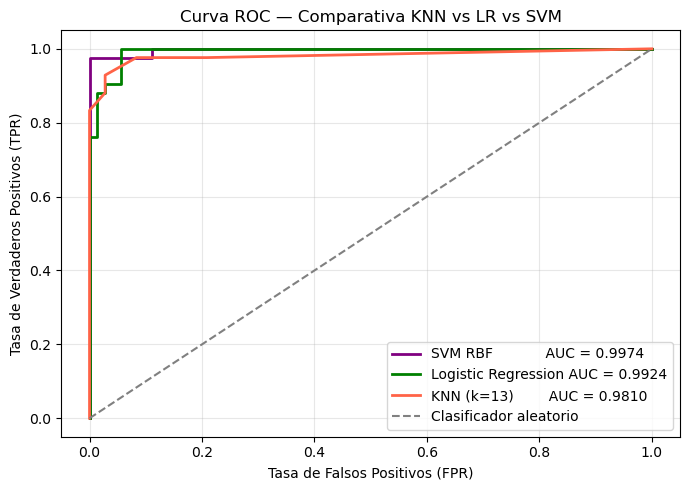

In [125]:

# Entrena SVM razonadamente
svm_rbf = SVC(kernel="rbf", C=5, gamma=0.01, probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf  = svm_rbf.predict(X_test_scaled)
y_proba_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

# Evalúa (accuracy + AUC + ROC)
acc_svm = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy : {acc_svm:.4f}")

auc_svm = roc_auc_score(y_test, y_proba_rbf)
print(f"AUC      : {auc_svm:.4f}")

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_rbf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, color="purple", lw=2, label=f"SVM RBF            AUC = {auc_svm:.4f}")
plt.plot(fpr_lr,  tpr_lr,  color="green",  lw=2, label=f"Logistic Regression AUC = {auc_lr:.4f}")
plt.plot(fpr,     tpr,     color="tomato", lw=2, label=f"KNN (k={k_final})        AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Clasificador aleatorio")
plt.title("Curva ROC — Comparativa KNN vs LR vs SVM")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🔟 Comparación final: ROC superpuestas + tabla

In [113]:

# Dibuja en el MISMO gráfico las ROC de:
# - KNN final
# - Regresión logística
# - SVM (elige la mejor versión: lineal o RBF)


# Puedes crear una tabla comparativa



---
## 1️⃣1️⃣ Conclusiones

Responde razonadamente:

1. ¿Qué modelo elegirías para este problema y por qué?
2. ¿Qué métrica te parece más relevante en un contexto médico: accuracy o AUC? Justifica tu respuesta.
3. Si el dataset fuera 100 veces más grande, ¿cuál de los tres modelos crees que sería menos recomendable y por qué?
4. ¿Cuál es el modelo más interpretable de los tres?
